# n-qubit GHZ state

This notebook demonstrates basic Qiskit coding by implementing the general n-qubit circuits discussed in Problem 3.11, the n-qubit GHZ state.

See also [this blog](https://egrettathula.wordpress.com/2024/03/24/efficient-circuit-for-ghz-state-preparation/) from Egretta Thula for some very nice code examples illustrating GHZ state preparation.

[![Open In Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Polaris-QCI/Quantum-Algorithms-and-Applications/main?labpath=Qiskit%2F03-Quantum-Circuit-Model-and-Query-Model%2Fproblem3.11-ghz.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Polaris-QCI/Quantum-Algorithms-and-Applications/blob/main/Qiskit/03-Quantum-Circuit-Model-and-Query-Model/problem3.11-ghz.ipynb)

# 0. Setup

The cells below install the packages and import the libraries needed by this demo.

In [ ]:
#@title Install Qiskit and other dependencies
%pip install matplotlib pylatexenc qiskit qiskit-aer qiskit-ibm-runtime

In [ ]:
# Imports

import io
import base64
import math

from IPython.display import HTML, display
from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.circuit.classical import expr
from qiskit.quantum_info import Statevector

# 1. Circuit Definitions

The following cell defines the first four circuits shown in the problem, for a general number of qubits. $n$ should be a power of 2 to illustrate the logarithmic depth of circuit (iv).

In [67]:
def create_circuit_i(n):
    """Creates the simple LNN version of the circuit."""
    qr = [QuantumRegister(1, f"q_{i+1}") for i in range(n)]
    circuit = QuantumCircuit(*qr)
    circuit.h(qr[0])
    for i in range(1, n):
        circuit.cx(qr[i-1], qr[i])
    return circuit


def create_circuit_ii(n):
    """Creates the circuit with half the depth, by parallelizing the CNOTs."""
    qr = [QuantumRegister(1, f"q_{i+1}") for i in range(n)]
    circuit = QuantumCircuit(*qr)
    mid = n // 2
    circuit.h(qr[mid-1])
    circuit.cx(qr[mid-1], qr[mid])
    for i in range(1, mid):
        circuit.cx(qr[mid-i], qr[mid-i-1])
        circuit.cx(qr[mid+i-1], qr[mid+i])
    return circuit


def create_circuit_iii(n):
    """Creates the circuit with CNOTs arranged to be able to be morphed into a tree."""
    qr = [QuantumRegister(1, f"q_{i+1}") for i in range(n)]
    circuit = QuantumCircuit(*qr)
    circuit.h(qr[0])
    levels = int(math.log2(n))
    for i in range(1, n):
        for j in range(levels):
            if (i+2**j) % 2**(j+1) == 0:
                circuit.cx(qr[i-1-j], qr[i])
                break
    return circuit    


def create_circuit_iv(n):
    """Creates the circuit with CNOTs arranged in a tree, for logarithmic depth."""
    qr = [QuantumRegister(1, f"q_{i+1}") for i in range(n)]
    circuit = QuantumCircuit(*qr)
    circuit.h(qr[0])
    levels = int(math.log2(n))
    for j in range(levels-1, -1, -1):
        step = 2**j
        for i in range(0, n, 2*step):
            circuit.cx(qr[i], qr[i+step])
    return circuit

# 2. Circuit diagrams

In [ ]:
n = 8 # 16 is probably the larget power of two that is practical for this notebook, since the statevector will have 2ⁿ amplitudes
circuit_i = create_circuit_i(n)
circuit_ii = create_circuit_ii(n)
circuit_iii = create_circuit_iii(n)
circuit_iv = create_circuit_iv(n)

def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


def circuit_to_html(title, circuit):
    fig = circuit.draw("mpl")
    img = fig_to_base64(fig)
    return f"""
    <div style="text-align:center;">
        <div><b>{title}</b></div>
        <img src="data:image/png;base64,{img}" style="max-width:100%;">
    </div>
    """


circuits = [
    ("i", circuit_i),
    ("ii", circuit_ii),
    ("iii", circuit_iii),
    ("iv", circuit_iv),
]


items = [circuit_to_html(title, circuit) for title, circuit in circuits]
html = f"""
<div style="
    display:grid;
    grid-template-columns: 1fr 1fr;
    gap:20px;
    align-items:start;
">
    {''.join(items)}
</div>
"""


display(HTML(html))

# 3. Statevector verification

In [ ]:
display(Statevector.from_instruction(circuit_i).draw('latex'))
display(Statevector.from_instruction(circuit_ii).draw('latex'))
display(Statevector.from_instruction(circuit_iii).draw('latex'))
display(Statevector.from_instruction(circuit_iv).draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>


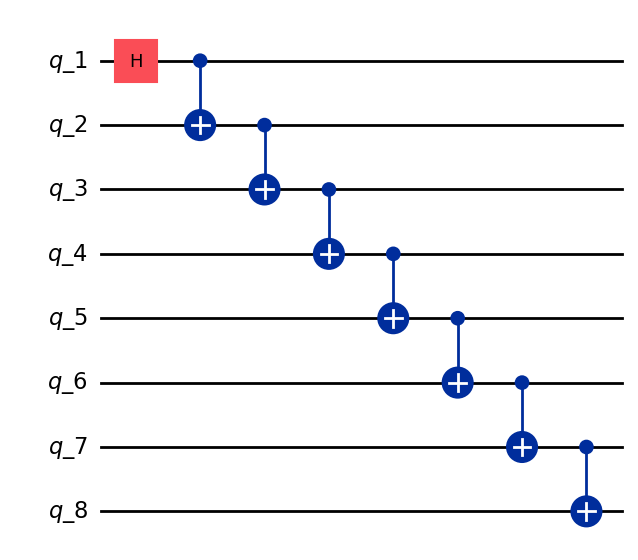
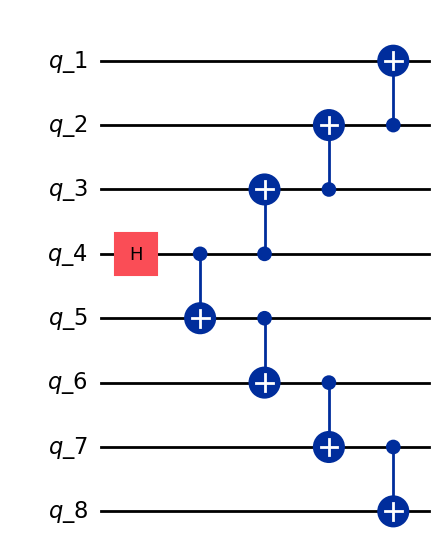
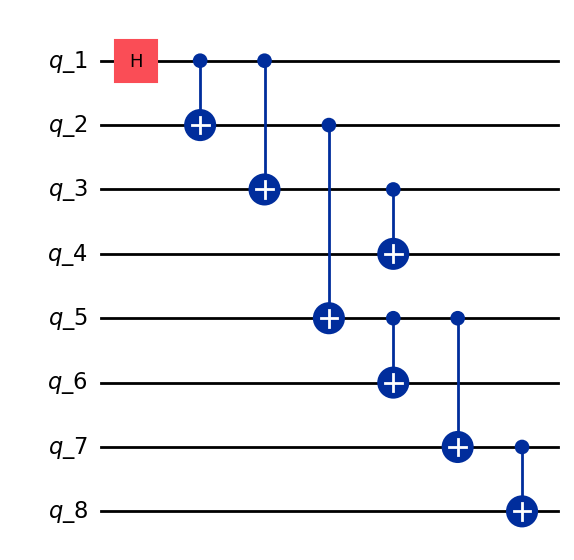
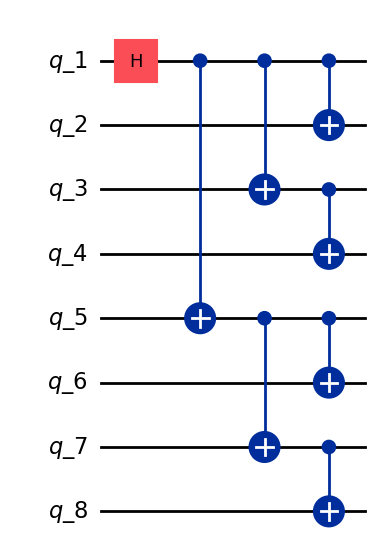

# 4. Constant-depth variant

Below is an adaptation of circuit (v) from the book to Qiskit, hardcoded for n=7. 

Note that there is a small correction to the book's circuits: one of the CNOTs is reversed. 

Also note that the classical control bit are combined with XOR, not AND, which is not clear from the diagram form.

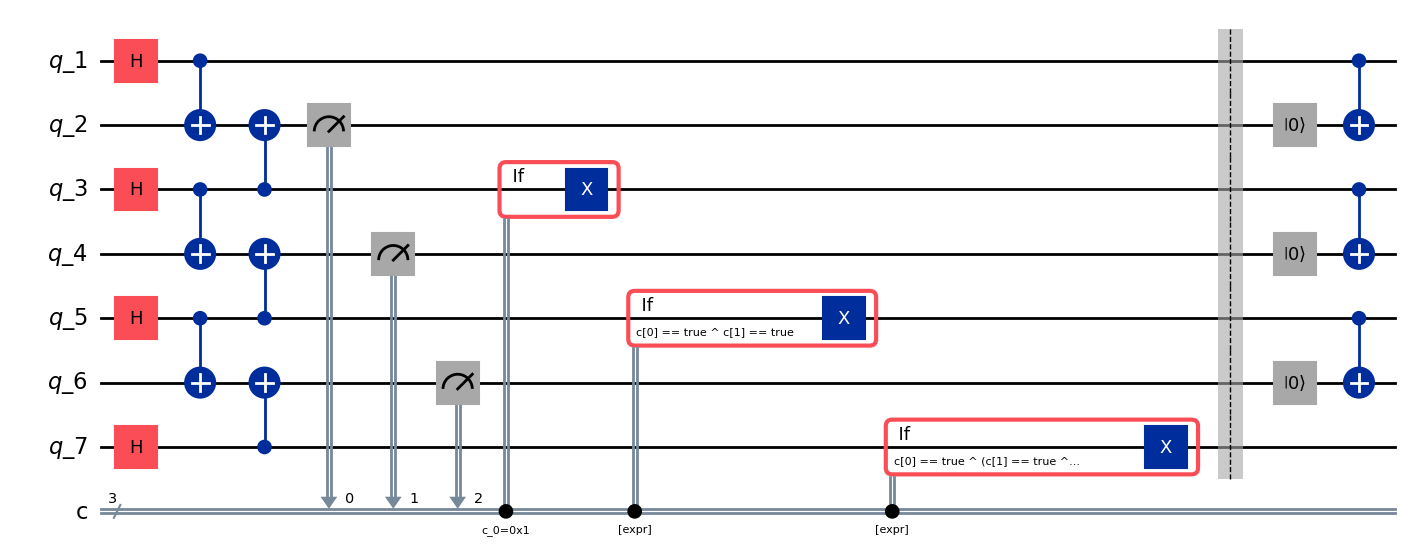

In [71]:
def create_circuit_v():
    """Constant depth on LNN, using mid-circuit measurements, feedforward and qubit reset/reuse."""
    qr = [QuantumRegister(1, f"q_{i+1}") for i in range(7)]
    cr = ClassicalRegister(3, "c")
    circuit = QuantumCircuit(*qr, cr)
    circuit.h(qr[0])
    circuit.h(qr[2])
    circuit.h(qr[4])
    circuit.h(qr[6])
    circuit.cx(qr[0], qr[1])
    circuit.cx(qr[2], qr[3])
    circuit.cx(qr[4], qr[5])
    circuit.cx(qr[2], qr[1])
    # circuit.cx(qr[3], qr[4]) # WRONG!
    circuit.cx(qr[4], qr[3]) # correct.
    circuit.cx(qr[6], qr[5])
    circuit.measure(qr[1], cr[0])
    circuit.measure(qr[3], cr[1])
    circuit.measure(qr[5], cr[2])
    with circuit.if_test((cr[0], 1)):
        circuit.x(qr[2])
    with circuit.if_test(expr.bit_xor(expr.equal(cr[0], True), expr.equal(cr[1], True))):
        circuit.x(qr[4])
    with circuit.if_test(expr.bit_xor(expr.equal(cr[0], True), expr.bit_xor(expr.equal(cr[1], True), expr.equal(cr[2], True)))):
        circuit.x(qr[6])
    circuit.barrier()    
    circuit.reset(qr[1])    
    circuit.reset(qr[3])
    circuit.reset(qr[5])
    circuit.cx(qr[0], qr[1])
    circuit.cx(qr[2], qr[3])
    circuit.cx(qr[4], qr[5])
               
    return circuit


circuit = create_circuit_v()
circuit.draw("mpl")


# 5. Verify result

We cannot get a Statevector for this circuit, because of the non-unitary operations (measurement and qubit reset).

Instead we run the circuit in the sampler and print the counts. We ignore the classical bits, and confirm that the qubit patterns correspond to the GHZ state.

In [72]:
# run circuit using Aer simulator for 1000 shots, and output the counts
from qiskit_aer import AerSimulator
simulator = AerSimulator()
circuit.measure_all()
# circuit.measure(qr)
counts = AerSimulator().run(circuit).result().get_counts()
print(counts)


{'0000000 001': 69, '1111111 100': 51, '1111111 101': 60, '1111111 011': 76, '1111111 001': 61, '0000000 101': 62, '1111111 000': 51, '1111111 010': 69, '0000000 011': 65, '0000000 111': 64, '0000000 010': 62, '0000000 000': 62, '1111111 111': 65, '1111111 110': 68, '0000000 100': 68, '0000000 110': 71}
